In [1]:
import pandas as pd
import numpy as np

In [2]:
#load the transaction and customer data 
transactions = pd.read_excel(r"C:\Users\Henry Bode\Downloads\QVI_transaction_data (1).xlsx")
customers= pd.read_csv(r"C:\Users\Henry Bode\Downloads\QVI_purchase_behaviour (1).csv")

In [3]:
print("transaction data shape",transactions.shape)
print ("\nfirst r rows:")
print (transactions.head())
print ("\nColumn names and types:")
print (transactions.dtypes)
print ("\nBasic statistics:")
print(transactions.describe())

transaction data shape (264836, 8)

first r rows:
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  

Column names and types:
DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int6

In [4]:
# understand data Quality
print("missing values in transction:")
print(transactions.isnull().sum())
print("missing values in customers:")
print(customers.isnull().sum())

missing values in transction:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64
missing values in customers:
LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


In [5]:
# unique values in categorical columns
print("\nunique Stores:", transactions["STORE_NBR"].nunique())
print("\nunique Products:", transactions["PROD_NBR"].nunique())
print("\nunique Customer:", transactions["LYLTY_CARD_NBR"].nunique())
# customer segment
print("\nlifestages categories:",customers["LIFESTAGE"].value_counts())
print ("\n premium customer categories:", customers ["PREMIUM_CUSTOMER"].value_counts())


unique Stores: 272

unique Products: 114

unique Customer: 72637

lifestages categories: LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

 premium customer categories: PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count, dtype: int64


In [6]:
# Check if DATE is already datetime or needs conversion
if transactions['DATE'].dtype == 'int64':
    # It's an Excel serial number - convert it
    print("Converting Excel serial number to datetime...")
    transactions['DATE'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(transactions['DATE'], 'D')
else:
    # It's already datetime - just make sure it's the right format
    print("DATE is already datetime format!")
    transactions['DATE'] = pd.to_datetime(transactions['DATE'])

print("Date range:", transactions['DATE'].min(), "to", transactions['DATE'].max())

# Extract useful date components
transactions['MONTH'] = transactions['DATE'].dt.month
transactions['YEAR'] = transactions['DATE'].dt.year
transactions['DAY_OF_WEEK'] = transactions['DATE'].dt.day_name()

print("\nFirst few dates after processing:")
print(transactions[['DATE', 'MONTH', 'YEAR', 'DAY_OF_WEEK']].head())

Converting Excel serial number to datetime...
Date range: 2018-07-01 00:00:00 to 2019-06-30 00:00:00

First few dates after processing:
        DATE  MONTH  YEAR DAY_OF_WEEK
0 2018-10-17     10  2018   Wednesday
1 2019-05-14      5  2019     Tuesday
2 2019-05-20      5  2019      Monday
3 2018-08-17      8  2018      Friday
4 2018-08-18      8  2018    Saturday


In [7]:
#finding and handling outliers
print("PROD_QTY statistics:",transactions['PROD_QTY'].describe())
print("\nTransactions with quantity >10:")
outliers=transactions[transactions['PROD_QTY']>10]
print(outliers[['DATE', 'LYLTY_CARD_NBR', 'PROD_NAME', 'PROD_QTY', 'TOT_SALES']])

# Investigate this customer
if  len(outliers) > 0:
    outlier_customer = outliers['LYLTY_CARD_NBR'].iloc[0]
    customer_history = transactions[transactions['LYLTY_CARD_NBR'] == outlier_customer]
    print(f"\nAll transactions for customer {outlier_customer}:")
    print(customer_history)


PROD_QTY statistics: count    264836.000000
mean          1.907309
std           0.643654
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64

Transactions with quantity >10:
            DATE  LYLTY_CARD_NBR                         PROD_NAME  PROD_QTY  \
69762 2018-08-19          226000  Dorito Corn Chp     Supreme 380g       200   
69763 2019-05-20          226000  Dorito Corn Chp     Supreme 380g       200   

       TOT_SALES  
69762      650.0  
69763      650.0  

All transactions for customer 226000:
            DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
69762 2018-08-19        226          226000  226201         4   
69763 2019-05-20        226          226000  226210         4   

                              PROD_NAME  PROD_QTY  TOT_SALES  MONTH  YEAR  \
69762  Dorito Corn Chp     Supreme 380g       200      650.0      8  2018   
69763  Dorito Corn Chp     Supreme 380g     

In [8]:
transactions_clean= transactions[transactions['LYLTY_CARD_NBR'] !=226000].copy()
print(f"Removed {len(transactions) - len(transactions_clean)} outlier transactions")

Removed 2 outlier transactions


In [9]:
import re

def extract_pack_size(product_name):
    """
    This function finds numbers followed by 'g' in the product name
    Example: "Smiths Chips 175g" -> 175
    """
    # re.search looks for a pattern in text
    # r'(\d+)\s*g' means: find digits followed by optional space and 'g'
    match = re.search(r'(\d+)\s*g', product_name, re.IGNORECASE)
    
    if match:
        return int(match.group(1))  # group(1) gets the number we captured
    return None

# Apply this function to every product name
transactions_clean['PACK_SIZE'] = transactions_clean['PROD_NAME'].apply(extract_pack_size)

# Check the results
print("Unique pack sizes found:")
print(sorted(transactions_clean['PACK_SIZE'].dropna().unique()))

print("\nProducts where we couldn't extract size:")
print(transactions_clean[transactions_clean['PACK_SIZE'].isna()]['PROD_NAME'].unique())

Unique pack sizes found:
[70, 90, 110, 125, 134, 135, 150, 160, 165, 170, 175, 180, 190, 200, 210, 220, 250, 270, 300, 330, 380]

Products where we couldn't extract size:
[]


In [10]:
def extract_brand(product_name):
    """
    Extract the brand name from product description
    Hint: Brand is usually the first word(s)
    """
    product_name = str(product_name).strip()
    
    # Dictionary of known brands
    brand_mapping = {
        'Smiths': 'Smiths',
        'Smith': 'Smiths',
        'Doritos': 'Doritos',
        'Dorito': 'Doritos',
        'Kettle': 'Kettle',
        'Pringles': 'Pringles',
        'Thins': 'Thins',
        'CCs': 'CCs',
        'Twisties': 'Twisties',
        'Grain Waves': 'Grain Waves',
        'GrnWves': 'Grain Waves',
        'WW': 'Woolworths',
        'Red Rock': 'Red Rock Deli',
        'RRD': 'Red Rock Deli',
        # Add more as you discover them!
    }
    
    # Check if any brand keyword is in the product name
    for keyword, brand in brand_mapping.items():
        if keyword.lower() in product_name.lower():
            return brand
    
    # If no match found, take first word
    return product_name.split()[0]

# Test it
transactions_clean['BRAND'] = transactions_clean['PROD_NAME'].apply(extract_brand)

print("Top 10 brands by transaction count:")
print(transactions_clean['BRAND'].value_counts().head(10))

Top 10 brands by transaction count:
BRAND
Kettle           41288
Smiths           31823
Doritos          28145
Pringles         25102
Red Rock Deli    17779
Woolworths       14757
Thins            14075
Infuzions        11057
Cobs              9693
Tostitos          9471
Name: count, dtype: int64


In [11]:
# Find products that contain "salsa" - these aren't chips!
salsa_products = transactions_clean['PROD_NAME'].str.contains('salsa', case=False, na=False)

print(f"Found {salsa_products.sum()} salsa transactions")
print("\nSample salsa products:")
print(transactions_clean[salsa_products]['PROD_NAME'].unique()[:5])

# Remove salsa products
transactions_clean = transactions_clean[~salsa_products].copy()
print(f"\nDataset now has {len(transactions_clean)} chip transactions")

Found 18094 salsa transactions

Sample salsa products:
['Old El Paso Salsa   Dip Tomato Mild 300g'
 'Red Rock Deli SR    Salsa & Mzzrlla 150g'
 'Smiths Crinkle Cut  Tomato Salsa 150g' 'Doritos Salsa       Medium 300g'
 'Old El Paso Salsa   Dip Chnky Tom Ht300g']

Dataset now has 246740 chip transactions


In [12]:
data= transactions_clean.merge(customers, on='LYLTY_CARD_NBR',how= 'left')
print("Merged data Shape:", data.shape)
print("\nCustomers without segment info:", data['LIFESTAGE'].isna().sum())
# create combined segment 
data['CUSTOMER_SEGEMT'] = data['LIFESTAGE']+'-'+data ['PREMIUM_CUSTOMER']
print ("\nSample of merged data:")
print (data[['LYLTY_CARD_NBR', 'PROD_NAME', 'TOT_SALES', 'LIFESTAGE', 'PREMIUM_CUSTOMER']].head())

Merged data Shape: (246740, 15)

Customers without segment info: 0

Sample of merged data:
   LYLTY_CARD_NBR                                 PROD_NAME  TOT_SALES  \
0            1000    Natural Chip        Compny SeaSalt175g        6.0   
1            1307                  CCs Nacho Cheese    175g        6.3   
2            1343    Smiths Crinkle Cut  Chips Chicken 170g        2.9   
3            2373    Smiths Chip Thinly  S/Cream&Onion 175g       15.0   
4            2426  Kettle Tortilla ChpsHny&Jlpno Chili 150g       13.8   

                LIFESTAGE PREMIUM_CUSTOMER  
0   YOUNG SINGLES/COUPLES          Premium  
1  MIDAGE SINGLES/COUPLES           Budget  
2  MIDAGE SINGLES/COUPLES           Budget  
3  MIDAGE SINGLES/COUPLES           Budget  
4  MIDAGE SINGLES/COUPLES           Budget  


In [13]:
# Price per unit
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']

# Price per 100g (for comparing different pack sizes)
data['PRICE_PER_100G'] = (data['TOT_SALES'] / data['PROD_QTY']) / (data['PACK_SIZE'] / 100)

# Categorize pack sizes
def categorize_pack_size(size):
    if size <= 150:
        return 'Small'
    elif size <= 200:
        return 'Medium'
    else:
        return 'Large'

data['PACK_SIZE_CATEGORY'] = data['PACK_SIZE'].apply(categorize_pack_size)

print("New columns created:")
print(data[['TOT_SALES', 'PROD_QTY', 'PACK_SIZE', 'PRICE_PER_UNIT', 
            'PRICE_PER_100G', 'PACK_SIZE_CATEGORY']].head())

New columns created:
   TOT_SALES  PROD_QTY  PACK_SIZE  PRICE_PER_UNIT  PRICE_PER_100G  \
0        6.0         2        175            3.00        1.714286   
1        6.3         3        175            2.10        1.200000   
2        2.9         2        170            1.45        0.852941   
3       15.0         5        175            3.00        1.714286   
4       13.8         3        150            4.60        3.066667   

  PACK_SIZE_CATEGORY  
0             Medium  
1             Medium  
2             Medium  
3             Medium  
4              Small  


In [23]:
print("\n" + "="*80)
print("CUSTOMER SEGMENT ANALYSIS")
print("="*80)

# Aggregate by customer segment
segment_analysis = data.groupby('CUSTOMER_SEGMENT').agg({
    'LYLTY_CARD_NBR': 'nunique',      # Count unique customers
    'TXN_ID': 'count',                 # Count transactions
    'TOT_SALES': 'sum',                # Total sales
    'PROD_QTY': 'sum',                 # Total units sold
    'PRICE_PER_UNIT': 'mean'           # Average price
}).round(2)

# Rename columns for clarity
segment_analysis.columns = ['Customers', 'Transactions', 'Total_Sales', 'Units_Sold', 'Avg_Price']

# Calculate additional metrics
segment_analysis['Avg_Spend_Per_Customer'] = (
    segment_analysis['Total_Sales'] / segment_analysis['Customers']
).round(2)

segment_analysis['Purchase_Frequency'] = (
    segment_analysis['Transactions'] / segment_analysis['Customers']
).round(2)

segment_analysis['Avg_Transaction_Value'] = (
    segment_analysis['Total_Sales'] / segment_analysis['Transactions']
).round(2)

segment_analysis['Sales_Share_Pct'] = (
    segment_analysis['Total_Sales'] / segment_analysis['Total_Sales'].sum() * 100
).round(2)

# Sort by total sales (highest first)
segment_analysis = segment_analysis.sort_values('Total_Sales', ascending=False)

print("\nTop 10 Customer Segments by Sales:")
print(segment_analysis.head(10))



CUSTOMER SEGMENT ANALYSIS

Top 10 Customer Segments by Sales:
                                    Customers  Transactions  Total_Sales  \
CUSTOMER_SEGMENT                                                           
OLDER FAMILIES - Budget                  4611         21514    156863.75   
YOUNG SINGLES/COUPLES - Mainstream       7917         19544    147582.20   
RETIREES - Mainstream                    6358         19970    145168.95   
YOUNG FAMILIES - Budget                  3953         17763    129717.95   
OLDER SINGLES/COUPLES - Budget           4849         17172    127833.60   
OLDER SINGLES/COUPLES - Mainstream       4858         17061    124648.50   
OLDER SINGLES/COUPLES - Premium          4682         16560    123537.55   
RETIREES - Budget                        4385         14225    105916.30   
OLDER FAMILIES - Mainstream              2788         13241     96413.55   
RETIREES - Premium                       3812         12236     91296.65   

                        

In [35]:
print("\n" + "="*80)
print("LIFESTAGE ANALYSIS")
print("="*80)

lifestage_analysis = data.groupby('LIFESTAGE').agg({
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count',
    'TOT_SALES': 'sum'
}).round(2)

lifestage_analysis.columns = ['Customers', 'Transactions', 'Total_Sales']

lifestage_analysis['Avg_Spend_Per_Customer'] = (
    lifestage_analysis['Total_Sales'] / lifestage_analysis['Customers']
).round(2)

lifestage_analysis['Purchase_Frequency'] = (
    lifestage_analysis['Transactions'] / lifestage_analysis['Customers']
).round(2)

lifestage_analysis['Sales_Share_Pct'] = (
    lifestage_analysis['Total_Sales'] / lifestage_analysis['Total_Sales'].sum() * 100
).round(2)

lifestage_analysis = lifestage_analysis.sort_values('Total_Sales', ascending=False)

print(lifestage_analysis)


LIFESTAGE ANALYSIS
                        Customers  Transactions  Total_Sales  \
LIFESTAGE                                                      
OLDER SINGLES/COUPLES       14389         50793    376019.65   
RETIREES                    14555         46431    342381.90   
OLDER FAMILIES               9630         45158    328519.90   
YOUNG FAMILIES               9036         40494    294627.90   
YOUNG SINGLES/COUPLES       14044         33969    243756.60   
MIDAGE SINGLES/COUPLES       7141         23398    172523.80   
NEW FAMILIES                 2492          6497     47347.95   

                        Avg_Spend_Per_Customer  Purchase_Frequency  \
LIFESTAGE                                                            
OLDER SINGLES/COUPLES                    26.13                3.53   
RETIREES                                 23.52                3.19   
OLDER FAMILIES                           34.11                4.69   
YOUNG FAMILIES                           32.61       

In [37]:
print("\n" + "="*80)
print("PREMIUM CUSTOMER TIER ANALYSIS")
print("="*80)

premium_analysis = data.groupby('PREMIUM_CUSTOMER').agg({
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count',
    'TOT_SALES': 'sum',
    'PRICE_PER_UNIT': 'mean'
}).round(2)

premium_analysis.columns = ['Customers', 'Transactions', 'Total_Sales', 'Avg_Price_Per_Unit']

premium_analysis['Avg_Spend_Per_Customer'] = (
    premium_analysis['Total_Sales'] / premium_analysis['Customers']
).round(2)

premium_analysis['Sales_Share_Pct'] = (
    premium_analysis['Total_Sales'] / premium_analysis['Total_Sales'].sum() * 100
).round(2)

premium_analysis = premium_analysis.sort_values('Total_Sales', ascending=False)

print(premium_analysis)


PREMIUM CUSTOMER TIER ANALYSIS
                  Customers  Transactions  Total_Sales  Avg_Price_Per_Unit  \
PREMIUM_CUSTOMER                                                             
Mainstream            28734         95043    700865.40                3.87   
Budget                24006         86762    631406.85                3.80   
Premium               18547         64935    472905.45                3.81   

                  Avg_Spend_Per_Customer  Sales_Share_Pct  
PREMIUM_CUSTOMER                                           
Mainstream                         24.39            38.83  
Budget                             26.30            34.98  
Premium                            25.50            26.20  


In [39]:
print("\n" + "="*80)
print("BRAND ANALYSIS")
print("="*80)

brand_analysis = data.groupby('BRAND').agg({
    'TOT_SALES': 'sum',
    'TXN_ID': 'count',
    'PRICE_PER_UNIT': 'mean'
}).round(2)

brand_analysis.columns = ['Total_Sales', 'Transactions', 'Avg_Price']

brand_analysis['Sales_Share_Pct'] = (
    brand_analysis['Total_Sales'] / brand_analysis['Total_Sales'].sum() * 100
).round(2)

brand_analysis = brand_analysis.sort_values('Total_Sales', ascending=False)

print("\nTop 10 Brands by Sales:")
print(brand_analysis.head(10))


BRAND ANALYSIS

Top 10 Brands by Sales:
               Total_Sales  Transactions  Avg_Price  Sales_Share_Pct
BRAND                                                               
Kettle            390239.8         41288       4.94            21.62
Doritos           226329.9         25224       4.68            12.54
Smiths            217492.0         30353       3.77            12.05
Pringles          177655.5         25102       3.70             9.84
Thins              88852.5         14075       3.30             4.92
Red Rock Deli      87607.5         16321       2.84             4.85
Twisties           81522.1          9454       4.50             4.52
Tostitos           79789.6          9471       4.40             4.42
Infuzions          76247.6         11057       3.61             4.22
Cobs               70569.8          9693       3.80             3.91


In [41]:
print("\n" + "="*80)
print("BRAND PREFERENCES BY TOP SEGMENTS")
print("="*80)

# Get top 5 segments
top_segments = segment_analysis.head(5).index.tolist()

for segment in top_segments:
    segment_data = data[data['CUSTOMER_SEGMENT'] == segment]
    top_brands = segment_data.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False).head(3)
    
    print(f"\n{segment}:")
    for brand, sales in top_brands.items():
        print(f"  {brand}: ${sales:,.2f}")


BRAND PREFERENCES BY TOP SEGMENTS

OLDER FAMILIES - Budget:
  Kettle: $32,058.00
  Smiths: $20,917.90
  Doritos: $18,555.55

YOUNG SINGLES/COUPLES - Mainstream:
  Kettle: $35,423.60
  Doritos: $20,925.90
  Pringles: $16,006.20

RETIREES - Mainstream:
  Kettle: $31,652.40
  Doritos: $18,531.55
  Smiths: $16,779.00

YOUNG FAMILIES - Budget:
  Kettle: $26,369.60
  Smiths: $16,738.60
  Doritos: $16,078.05

OLDER SINGLES/COUPLES - Budget:
  Kettle: $29,066.40
  Doritos: $15,806.60
  Smiths: $14,820.60


In [43]:
print("\n" + "="*80)
print("PACK SIZE PREFERENCES")
print("="*80)

# Pack size by lifestage (as percentage)
pack_by_lifestage = pd.crosstab(
    data['LIFESTAGE'],
    data['PACK_SIZE_CATEGORY'],
    values=data['TOT_SALES'],
    aggfunc='sum',
    normalize='index'  # This gives percentages within each lifestage
) * 100

print("\nPack Size Preference by Lifestage (% of sales):")
print(pack_by_lifestage.round(1))

# Pack size by premium tier
pack_by_premium = pd.crosstab(
    data['PREMIUM_CUSTOMER'],
    data['PACK_SIZE_CATEGORY'],
    values=data['TOT_SALES'],
    aggfunc='sum',
    normalize='index'
) * 100

print("\nPack Size Preference by Premium Tier (% of sales):")
print(pack_by_premium.round(1))


PACK SIZE PREFERENCES

Pack Size Preference by Lifestage (% of sales):
PACK_SIZE_CATEGORY      Large  Medium  Small
LIFESTAGE                                   
MIDAGE SINGLES/COUPLES   19.4    43.0   37.6
NEW FAMILIES             18.9    42.6   38.5
OLDER FAMILIES           18.5    44.6   36.8
OLDER SINGLES/COUPLES    19.1    42.9   38.1
RETIREES                 19.4    42.6   37.9
YOUNG FAMILIES           18.2    44.9   36.9
YOUNG SINGLES/COUPLES    19.9    42.2   38.0

Pack Size Preference by Premium Tier (% of sales):
PACK_SIZE_CATEGORY  Large  Medium  Small
PREMIUM_CUSTOMER                        
Budget               18.8    43.9   37.3
Mainstream           19.4    42.7   37.9
Premium              18.9    43.6   37.5


In [45]:
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save cleaned dataset
data.to_csv('chips_cleaned_data.csv', index=False)
print("✓ Saved: chips_cleaned_data.csv")

# Save segment analysis
segment_analysis.to_csv('segment_analysis.csv')
print("✓ Saved: segment_analysis.csv")

# Save lifestage analysis
lifestage_analysis.to_csv('lifestage_analysis.csv')
print("✓ Saved: lifestage_analysis.csv")

# Save brand analysis
brand_analysis.to_csv('brand_analysis.csv')
print("✓ Saved: brand_analysis.csv")


SAVING RESULTS
✓ Saved: chips_cleaned_data.csv
✓ Saved: segment_analysis.csv
✓ Saved: lifestage_analysis.csv
✓ Saved: brand_analysis.csv



CREATING VISUALIZATIONS
✓ Saved: chips_dashboard.png


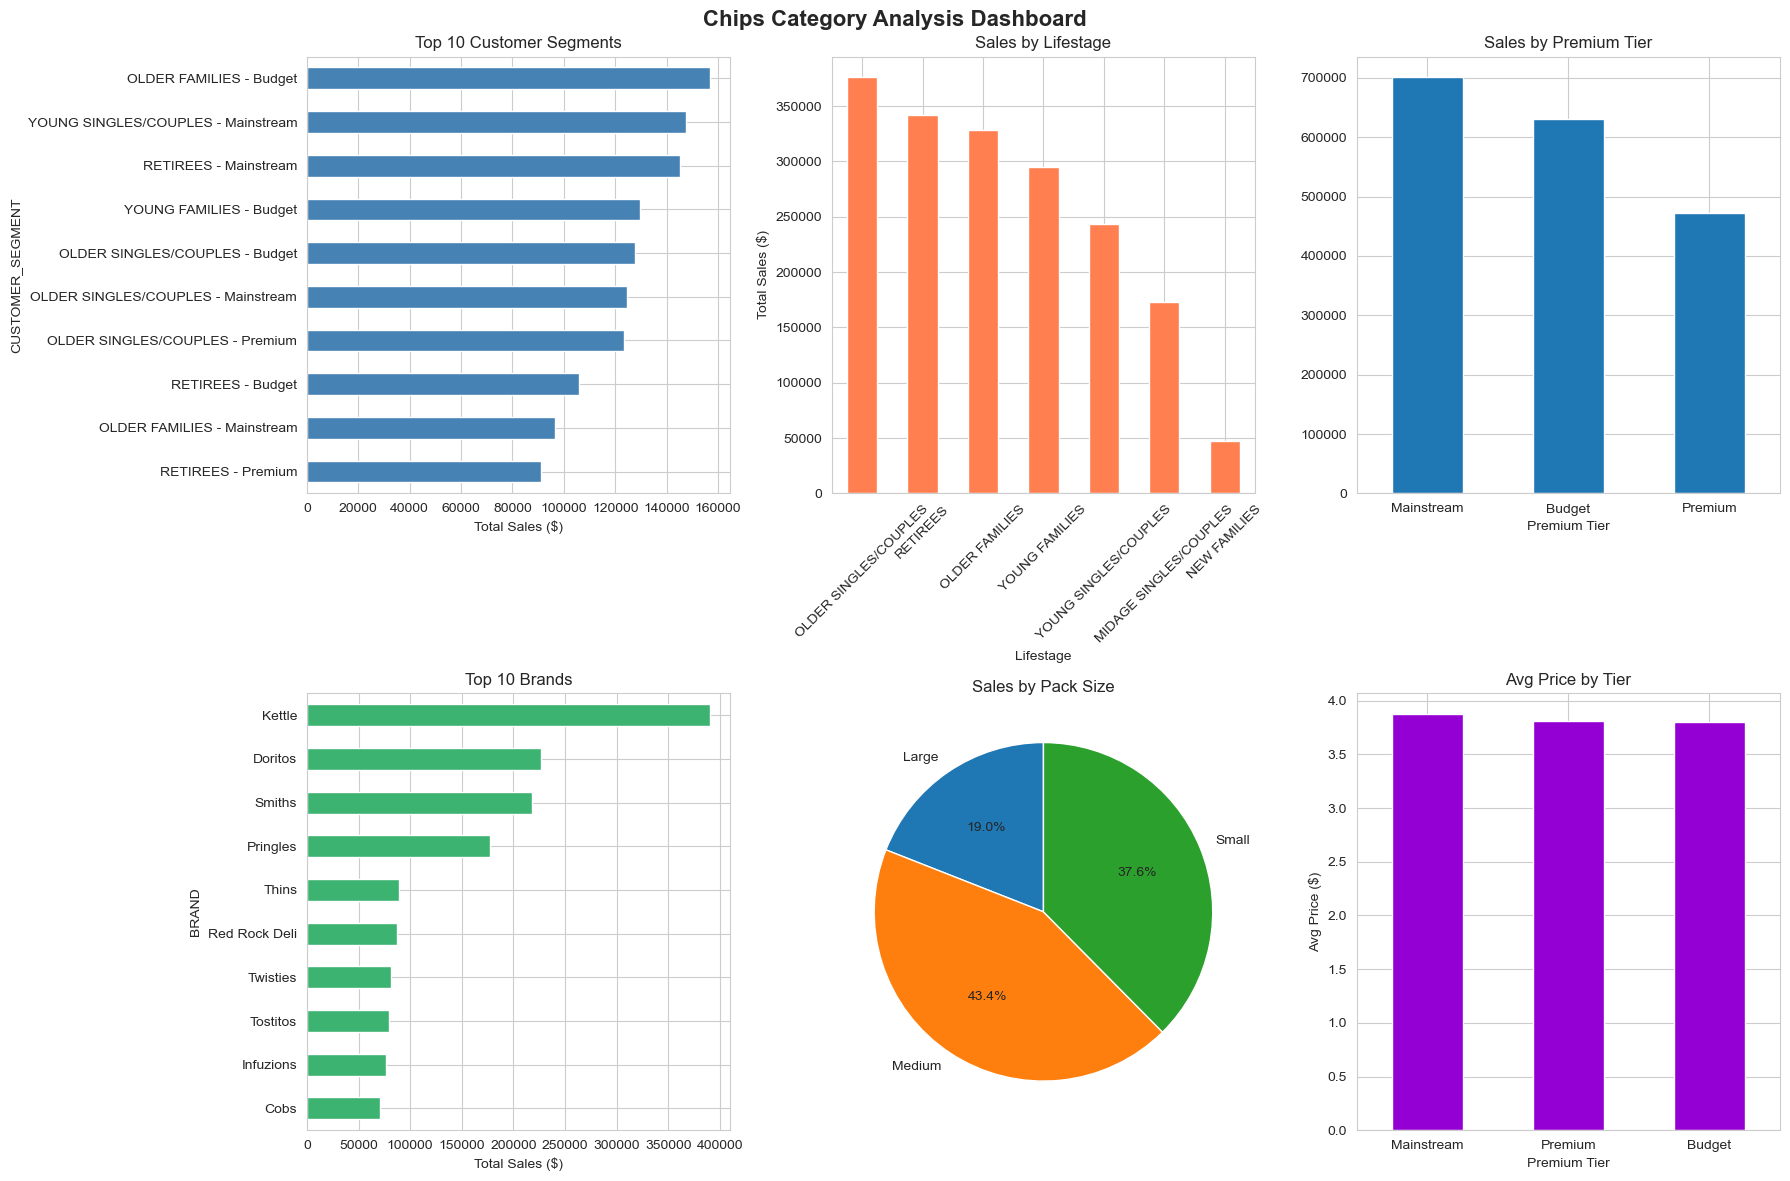

✓ Saved: monthly_trend.png


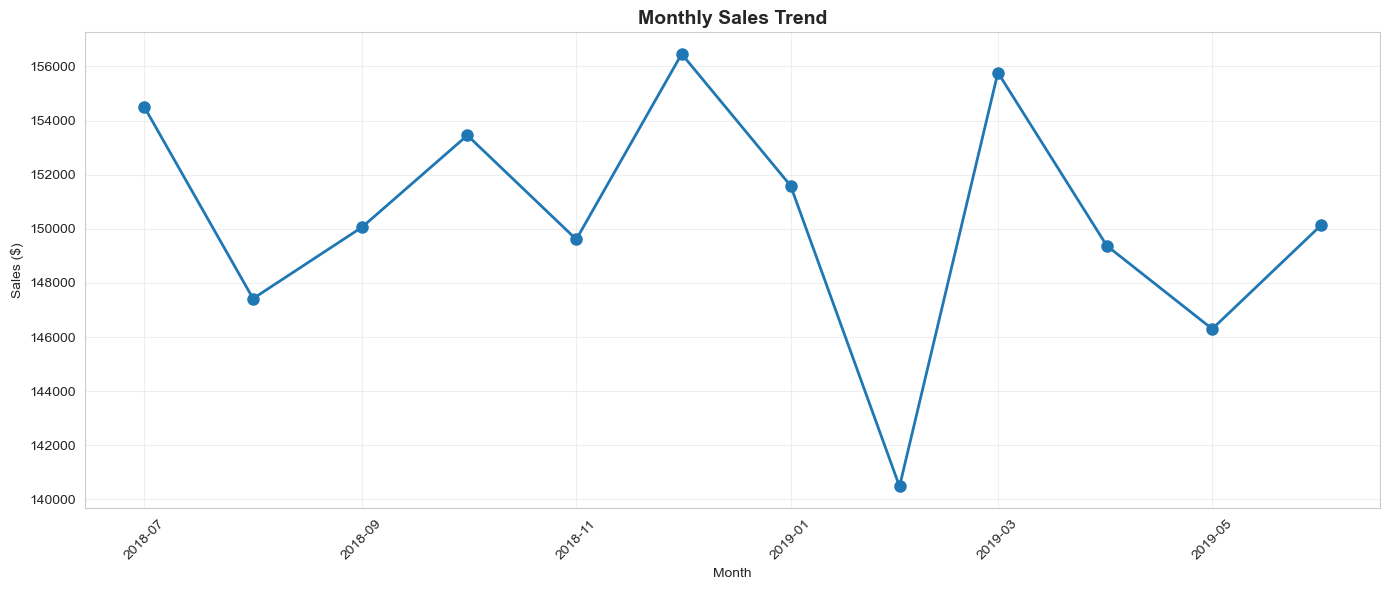


✅ ANALYSIS COMPLETE!

🎯 KEY INSIGHTS:
Top Segment: OLDER FAMILIES - Budget
  Sales: $156,863.75 (8.69%)

Top Brand: Kettle
  Sales: $390,239.80

Total Sales: $1,805,177.70
Total Customers: 71,287

📁 Files created:
  ✓ chips_cleaned_data.csv
  ✓ segment_analysis.csv
  ✓ lifestage_analysis.csv
  ✓ brand_analysis.csv
  ✓ chips_dashboard.png
  ✓ monthly_trend.png

🚀 YOU DID IT! Ready for your Quantium presentation!


In [59]:
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Dashboard with 6 charts
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Chips Category Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Top segments
ax1 = axes[0, 0]
segment_analysis.head(10)['Total_Sales'].plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Total Sales ($)')
ax1.set_title('Top 10 Customer Segments')
ax1.invert_yaxis()

# 2. Lifestage
ax2 = axes[0, 1]
data.groupby('LIFESTAGE')['TOT_SALES'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax2, color='coral')
ax2.set_xlabel('Lifestage')
ax2.set_ylabel('Total Sales ($)')
ax2.set_title('Sales by Lifestage')
ax2.tick_params(axis='x', rotation=45)

# 3. Premium tier
ax3 = axes[0, 2]
data.groupby('PREMIUM_CUSTOMER')['TOT_SALES'].sum().sort_values(ascending=False).plot(kind='bar', ax=ax3)
ax3.set_xlabel('Premium Tier')
ax3.set_title('Sales by Premium Tier')
ax3.tick_params(axis='x', rotation=0)

# 4. Brands
ax4 = axes[1, 0]
brand_analysis.head(10)['Total_Sales'].plot(kind='barh', ax=ax4, color='mediumseagreen')
ax4.set_xlabel('Total Sales ($)')
ax4.set_title('Top 10 Brands')
ax4.invert_yaxis()

# 5. Pack size
ax5 = axes[1, 1]
data.groupby('PACK_SIZE_CATEGORY')['TOT_SALES'].sum().plot(kind='pie', ax=ax5, autopct='%1.1f%%', startangle=90)
ax5.set_ylabel('')
ax5.set_title('Sales by Pack Size')

# 6. Price by tier
ax6 = axes[1, 2]
data.groupby('PREMIUM_CUSTOMER')['PRICE_PER_UNIT'].mean().sort_values(ascending=False).plot(kind='bar', ax=ax6, color='darkviolet')
ax6.set_xlabel('Premium Tier')
ax6.set_ylabel('Avg Price ($)')
ax6.set_title('Avg Price by Tier')
ax6.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chips_dashboard.png', dpi=300, bbox_inches='tight')
print("✓ Saved: chips_dashboard.png")
plt.show()

# Monthly trend
plt.figure(figsize=(14, 6))
monthly = data.groupby(data['DATE'].dt.to_period('M'))['TOT_SALES'].sum()
monthly.index = monthly.index.to_timestamp()
plt.plot(monthly.index, monthly.values, marker='o', linewidth=2, markersize=8)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300)
print("✓ Saved: monthly_trend.png")
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)

print(f"\n🎯 KEY INSIGHTS:")
print(f"Top Segment: {segment_analysis.index[0]}")
print(f"  Sales: ${segment_analysis.iloc[0]['Total_Sales']:,.2f} ({segment_analysis.iloc[0]['Sales_Share_Pct']}%)")
print(f"\nTop Brand: {brand_analysis.index[0]}")
print(f"  Sales: ${brand_analysis.iloc[0]['Total_Sales']:,.2f}")
print(f"\nTotal Sales: ${data['TOT_SALES'].sum():,.2f}")
print(f"Total Customers: {data['LYLTY_CARD_NBR'].nunique():,}")

print("\n📁 Files created:")
print("  ✓ chips_cleaned_data.csv")
print("  ✓ segment_analysis.csv")
print("  ✓ lifestage_analysis.csv")
print("  ✓ brand_analysis.csv")
print("  ✓ chips_dashboard.png")
print("  ✓ monthly_trend.png")

print("\n🚀 YOU DID IT! Ready for your Quantium presentation!")